# Unit 4 Hands-On ①: REINFORCE — CartPole-v1 실습

이 노트북은 **Hugging Face 딥 강화학습 강좌 Unit 4**의 첫 번째 실습입니다.  
**REINFORCE(Policy Gradient)** 알고리즘을 **직접 PyTorch로 구현**하여  
`CartPole-v1` 환경에서 에이전트를 훈련합니다.

### Unit 3(DQN)과의 차이점

| 항목 | Unit 3 (DQN) | Unit 4 (REINFORCE) |
|---|---|---|
| **학습 대상** | Q값 (가치 함수) | 정책(Policy) 직접 학습 |
| **접근법** | Value-based | Policy-based |
| **네트워크 출력** | 각 행동의 Q값 | 각 행동의 확률 |
| **탐색 방식** | ε-greedy | 확률적 샘플링 |

### REINFORCE 알고리즘 요약
```
에피소드 실행 → 보상 수집 → 누적 할인 보상(Return) 계산
     → 정책 손실(Policy Loss) 계산 → 역전파 → 정책 업데이트
```

---
## 목차
1. 환경 설치
2. Google Drive 마운트
3. 가상 디스플레이 설정
4. 라이브러리 임포트
5. 환경 탐색
6. 정책 네트워크 정의
7. REINFORCE 훈련 함수
8. 하이퍼파라미터 설정 및 훈련
9. 훈련 곡선 시각화
10. 에이전트 평가
11. 훈련 과정 영상 저장
12. Hugging Face Hub 업로드


---
## 1. 환경 설치

CartPole-v1 실행에 필요한 패키지를 설치합니다.


In [1]:
!apt install -y python-opengl ffmpeg xvfb -qq
!pip install pyvirtualdisplay gymnasium huggingface_hub imageio imageio-ffmpeg -q

E: Unable to locate package python-opengl


---
## 2. Google Drive 마운트

Colab VM은 세션 종료 시 파일이 삭제됩니다.  
훈련 영상과 모델을 Google Drive에 저장합니다.

```
Google Drive/RL_Course/Unit4_CartPole/
├── training_videos/   ← 훈련 중간 영상
└── model.pt           ← 최종 모델 (HF Hub 업로드 전 백업)
```


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ✏️ 저장 폴더명을 원하는 대로 변경하세요.
DRIVE_BASE = '/content/drive/MyDrive/RL_Course/Unit4_CartPole'
VIDEO_DIR  = f'{DRIVE_BASE}/training_videos'
MODEL_DIR  = DRIVE_BASE

os.makedirs(VIDEO_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ Drive 마운트 완료!')
print(f'   영상 저장 경로 : {VIDEO_DIR}')
print(f'   모델 저장 경로 : {MODEL_DIR}')


Mounted at /content/drive
✅ Drive 마운트 완료!
   영상 저장 경로 : /content/drive/MyDrive/RL_Course/Unit4_CartPole/training_videos
   모델 저장 경로 : /content/drive/MyDrive/RL_Course/Unit4_CartPole


---
## 3. 가상 디스플레이 설정

Colab에는 물리적 화면이 없으므로 가상 디스플레이를 생성합니다.  
`render_mode='rgb_array'`로 프레임을 배열로 받아 mp4로 저장합니다.


In [3]:
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()
print('✅ 가상 디스플레이 시작')


✅ 가상 디스플레이 시작


---
## 4. 라이브러리 임포트

| 라이브러리 | 역할 |
|---|---|
| `torch` | 신경망 정의 및 역전파 |
| `torch.distributions.Categorical` | 확률 분포에서 행동 샘플링 |
| `gymnasium` | CartPole 환경 |
| `imageio` | 프레임을 mp4로 저장 |
| `matplotlib` | 훈련 곡선 시각화 |


In [4]:
import numpy as np
import glob
from collections import deque

import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium as gym
import imageio

from huggingface_hub import HfApi, snapshot_download, login
from huggingface_hub.repocard import metadata_eval_result, metadata_save
from IPython.display import Video, display
from pathlib import Path
import datetime, json, tempfile


In [5]:
# GPU 사용 가능 여부 확인
# REINFORCE + MLP는 연산량이 작아 CPU로도 충분히 빠름
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('사용 디바이스:', device)


사용 디바이스: cpu


---
## 5. 환경 탐색

### CartPole-v1 이란?

카트 위에 놓인 막대를 쓰러뜨리지 않고 최대한 오래 균형을 유지하는 환경입니다.

```
        |
       /|\
      / | \
  ───[cart]───
  ←→ (좌우 이동)
```

**관측 공간** (4개 연속값):
- 카트 위치 / 카트 속도 / 막대 각도 / 막대 각속도

**행동 공간** (2개):
- 0: 카트를 왼쪽으로 밀기
- 1: 카트를 오른쪽으로 밀기

**보상**: 매 스텝마다 +1 (막대가 쓰러지지 않는 한)
**성공 기준**: 최근 100 에피소드 평균 점수 **475점 이상**


In [6]:
env_id = 'CartPole-v1'

# 훈련용 환경
env = gym.make(env_id)

# 평가용 환경 (훈련 환경과 분리)
eval_env = gym.make(env_id)

# 상태 공간 / 행동 공간 크기
s_size = env.observation_space.shape[0]  # 4
a_size = env.action_space.n              # 2

print('===== 관측 공간(Observation Space) =====')
print('크기:', s_size, '→ [카트위치, 카트속도, 막대각도, 막대각속도]')
print('샘플:', env.observation_space.sample())

print('\n===== 행동 공간(Action Space) =====')
print('크기:', a_size, '→ 0: 왼쪽, 1: 오른쪽')


===== 관측 공간(Observation Space) =====
크기: 4 → [카트위치, 카트속도, 막대각도, 막대각속도]
샘플: [-4.415532   -0.48151445  0.21704534 -0.09813009]

===== 행동 공간(Action Space) =====
크기: 2 → 0: 왼쪽, 1: 오른쪽


---
## 6. 정책 네트워크 (Policy Network)

REINFORCE는 Q값 대신 **행동 확률을 직접 출력**하는 신경망을 학습합니다.

```
입력 (상태 s, 4차원)
     │
  FC Layer 1  (4 → h_size, ReLU)
     │
  FC Layer 2  (h_size → 2)
     │
  Softmax     → [P(왼쪽), P(오른쪽)]  (확률 합 = 1)
     │
  Categorical 분포에서 행동 샘플링
```

**`act()` 메서드**:
- 상태를 텐서로 변환 → 순전파 → 확률 분포 생성
- 확률에 비례해 행동 샘플링 (확률적 정책)
- 행동과 함께 `log_prob`(로그 확률) 반환 → 손실 계산에 사용


In [7]:
class Policy(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(s_size, h_size)
        self.fc2 = nn.Linear(h_size, a_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=1)  # 행동 확률 반환

    def act(self, state):
        """상태를 받아 행동과 log_prob 반환"""
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()           # 행동 확률
        m = Categorical(probs)                      # 확률 분포 생성
        action = m.sample()                         # 확률에 비례해 행동 샘플링
        return action.item(), m.log_prob(action)    # (행동, 로그확률)


---
## 7. REINFORCE 훈련 함수

### 알고리즘 흐름

```
에피소드 실행
  └─ 매 스텝: 정책으로 행동 선택, 보상 수집, log_prob 저장

누적 할인 보상(Return) G_t 계산
  └─ G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ...
  └─ 역방향으로 O(N) 계산 (dynamic programming)

Return 정규화 (평균 0, 표준편차 1)
  └─ 훈련 안정화 목적

정책 손실 계산
  └─ Loss = -Σ log_prob(a_t) × G_t
  └─ 높은 보상을 받은 행동의 확률을 높이도록 학습

역전파 및 파라미터 업데이트
```

**정책 손실 공식**:  
$$\mathcal{L} = -\sum_t \log \pi_\theta(a_t|s_t) \cdot G_t$$


In [8]:
def reinforce(policy, optimizer, n_training_episodes, max_t, gamma, print_every):
    """
    REINFORCE(Monte Carlo Policy Gradient) 훈련 루프

    Args:
        policy: 정책 네트워크
        optimizer: 옵티마이저
        n_training_episodes: 총 훈련 에피소드 수
        max_t: 에피소드당 최대 스텝
        gamma: 할인율
        print_every: 몇 에피소드마다 로그 출력
    """
    scores_deque = deque(maxlen=100)  # 최근 100 에피소드 점수
    scores = []                        # 전체 에피소드 점수 기록

    for i_episode in range(1, n_training_episodes + 1):
        saved_log_probs = []  # 각 스텝의 log P(action|state)
        rewards = []          # 각 스텝의 보상

        state, info = env.reset()

        # ── 에피소드 실행 ──────────────────────────────────────────
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                break

        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # ── 누적 할인 보상(Return) 계산 ───────────────────────────
        # G_t = r_t + γ·G_{t+1} 를 역방향으로 O(N) 계산
        returns = deque(maxlen=max_t)
        for t in range(len(rewards))[::-1]:
            disc_return_t = returns[0] if len(returns) > 0 else 0
            returns.appendleft(gamma * disc_return_t + rewards[t])

        # ── Return 정규화 (훈련 안정화) ───────────────────────────
        eps = np.finfo(np.float32).eps.item()  # 수치 안정성을 위한 작은 값
        returns = torch.tensor(returns)
        std_returns = returns.std()
        if std_returns == 0:  # std=0 이면 NaN 방지
            returns = returns * 0
        else:
            returns = (returns - returns.mean()) / (std_returns + eps)

        # ── 정책 손실 계산: Loss = -Σ log_prob × G_t ─────────────
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return)
        policy_loss = torch.cat(policy_loss).sum()

        # ── 역전파 및 파라미터 업데이트 ───────────────────────────
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print(f'에피소드 {i_episode}\t최근 100회 평균 점수: {np.mean(scores_deque):.2f}')

    return scores


---
## 8. 하이퍼파라미터 설정 및 훈련

| 파라미터 | 값 | 설명 |
|---|---|---|
| `h_size` | 16 | 은닉층 크기 |
| `n_training_episodes` | 1,000 | 총 훈련 에피소드 |
| `max_t` | 1,000 | 에피소드당 최대 스텝 |
| `gamma` | 1.0 | 할인율 (CartPole은 단기 에피소드라 1.0 사용) |
| `lr` | 1e-2 | 학습률 |


In [11]:
cartpole_hyperparameters = {
    'h_size': 16,
    'n_training_episodes': 1000,
    'n_evaluation_episodes': 10,
    'max_t': 1000,
    'gamma': 1.0,
    'lr': 1e-2,
    'env_id': env_id,
    'state_space': s_size,
    'action_space': a_size,
}


In [12]:
# 정책 네트워크 및 옵티마이저 생성
cartpole_policy = Policy(
    cartpole_hyperparameters['state_space'],
    cartpole_hyperparameters['action_space'],
    cartpole_hyperparameters['h_size'],
).to(device)

cartpole_optimizer = optim.Adam(
    cartpole_policy.parameters(),
    lr=cartpole_hyperparameters['lr']
)

# 훈련 실행
scores = reinforce(
    cartpole_policy,
    cartpole_optimizer,
    cartpole_hyperparameters['n_training_episodes'],
    cartpole_hyperparameters['max_t'],
    cartpole_hyperparameters['gamma'],
    print_every=100,
)


에피소드 100	최근 100회 평균 점수: 46.17
에피소드 200	최근 100회 평균 점수: 271.81
에피소드 300	최근 100회 평균 점수: 483.89
에피소드 400	최근 100회 평균 점수: 450.37
에피소드 500	최근 100회 평균 점수: 500.00
에피소드 600	최근 100회 평균 점수: 490.53
에피소드 700	최근 100회 평균 점수: 492.41
에피소드 800	최근 100회 평균 점수: 473.59
에피소드 900	최근 100회 평균 점수: 473.78
에피소드 1000	최근 100회 평균 점수: 466.97


---
## 9. 훈련 곡선 시각화

에피소드별 점수와 이동 평균을 그래프로 확인합니다.  
점수가 **475점** 이상이면 CartPole-v1 해결 기준을 달성한 것입니다.


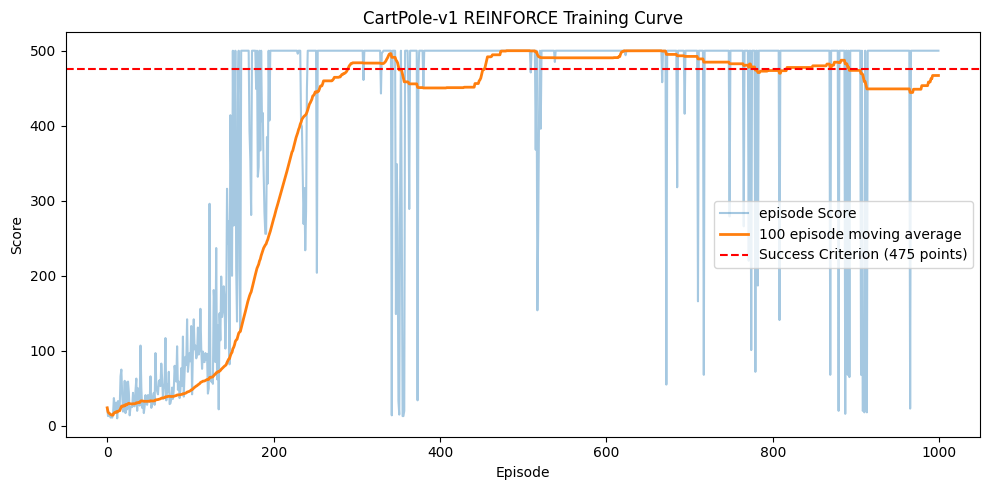

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(scores, alpha=0.4, label='episode Score')

# 100 에피소드 이동 평균
if len(scores) >= 100:
    moving_avg = [np.mean(scores[max(0, i-99):i+1]) for i in range(len(scores))]
    ax.plot(moving_avg, label='100 episode moving average', linewidth=2)

ax.axhline(y=475, color='r', linestyle='--', label='Success Criterion (475 points)')
ax.set_xlabel('Episode')
ax.set_ylabel('Score')
ax.set_title('CartPole-v1 REINFORCE Training Curve')
ax.legend()
plt.tight_layout()
plt.show()


---
## 10. 에이전트 평가

10번의 에피소드로 평균 보상을 측정합니다.  
평가 시에는 `policy.act()`가 확률적으로 행동을 선택합니다.


In [15]:
def evaluate_agent(env, max_steps, n_eval_episodes, policy):
    """
    n_eval_episodes 동안 에이전트를 실행하여 평균 보상 반환

    Args:
        env: 평가 환경
        max_steps: 에피소드당 최대 스텝
        n_eval_episodes: 평가 에피소드 수
        policy: REINFORCE 정책 네트워크
    """
    episode_rewards = []

    for episode in range(n_eval_episodes):
        state, info = env.reset()
        total_reward = 0.0

        for step in range(max_steps):
            action, _ = policy.act(state)
            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break

        episode_rewards.append(total_reward)

    return np.mean(episode_rewards), np.std(episode_rewards)


mean_reward, std_reward = evaluate_agent(
    eval_env,
    cartpole_hyperparameters['max_t'],
    cartpole_hyperparameters['n_evaluation_episodes'],
    cartpole_policy
)
print(f'평균 보상: {mean_reward:.2f} ± {std_reward:.2f}')
print('(475점 이상이면 성공적으로 학습된 것)')


평균 보상: 500.00 ± 0.00
(475점 이상이면 성공적으로 학습된 것)


---
## 11. 훈련 과정 영상 저장

현재 정책으로 1 에피소드를 실행하여 mp4로 저장하고 노트북에서 재생합니다.  
훈련 전/후를 비교하려면 훈련 전에도 이 셀을 실행해두세요.


In [16]:
def record_video(env_id, policy, video_path, max_steps=1000, fps=30):
    """
    현재 정책으로 1 에피소드를 실행하여 mp4로 저장

    Args:
        env_id: 환경 ID
        policy: REINFORCE 정책 네트워크
        video_path: 저장할 mp4 파일 경로
        max_steps: 최대 스텝 수
        fps: 영상 프레임레이트
    """
    # rgb_array 모드: 픽셀 프레임을 numpy 배열로 반환 (커널 크래시 없음)
    record_env = gym.make(env_id, render_mode='rgb_array')
    frames = []

    state, info = record_env.reset()
    frames.append(record_env.render())

    for _ in range(max_steps):
        action, _ = policy.act(state)
        state, reward, terminated, truncated, info = record_env.step(action)
        frames.append(record_env.render())
        if terminated or truncated:
            break

    record_env.close()
    imageio.mimsave(video_path, [np.array(f) for f in frames], fps=fps)
    print(f'✅ 영상 저장 완료: {video_path}')


# 훈련 완료 후 영상 저장
video_path = f'{VIDEO_DIR}/cartpole_trained.mp4'
record_video(env_id, cartpole_policy, video_path)

# 노트북에서 바로 재생
display(Video(video_path, embed=True, width=400))


✅ 영상 저장 완료: /content/drive/MyDrive/RL_Course/Unit4_CartPole/training_videos/cartpole_trained.mp4


---
## 12. Hugging Face Hub 업로드

훈련된 정책 네트워크를 HF Hub에 업로드합니다.

### 사전 준비
1. [Hugging Face 계정 생성](https://huggingface.co/join)
2. [쓰기(write) 권한 토큰 발급](https://huggingface.co/settings/tokens)


In [17]:
from huggingface_hub import login

# ✏️ 본인의 HF 토큰으로 교체하세요
# ⚠️ 토큰은 절대 외부에 공개하지 마세요!
login(token='hf_xxxxxxxxxxxxxxxxxxxxxxxx')


In [20]:
def to_jsonable(obj):
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f'Object of type {type(obj).__name__} is not JSON serializable')


def push_to_hub(repo_id, model, hyperparameters, eval_env, video_fps=30):
    """
    평가 → 영상 생성 → HF Hub 업로드 전체 파이프라인

    Args:
        repo_id: HF Hub 저장소 ID (예: 'username/Reinforce-CartPole-v1')
        model: 업로드할 정책 네트워크
        hyperparameters: 훈련 하이퍼파라미터 딕셔너리
        eval_env: 평가 환경
        video_fps: 영상 프레임레이트
    """
    _, repo_name = repo_id.split('/')
    api = HfApi()

    # Step 1: HF Hub 저장소 생성 (이미 있으면 그대로 사용)
    repo_url = api.create_repo(repo_id=repo_id, exist_ok=True)

    with tempfile.TemporaryDirectory() as tmpdirname:
        local_dir = Path(tmpdirname)

        # Step 2: 모델 저장
        torch.save(model, local_dir / 'model.pt')

        # Step 3: 하이퍼파라미터 JSON 저장
        with open(local_dir / 'hyperparameters.json', 'w') as f:
            json.dump(hyperparameters, f, default=to_jsonable)

        # Step 4: 평가 결과 JSON 저장
        mean_reward, std_reward = evaluate_agent(
            eval_env, hyperparameters['max_t'],
            hyperparameters['n_evaluation_episodes'], model
        )
        with open(local_dir / 'results.json', 'w') as f:
            json.dump({
                'env_id': hyperparameters['env_id'],
                'mean_reward': mean_reward,
                'n_evaluation_episodes': hyperparameters['n_evaluation_episodes'],
                'eval_datetime': datetime.datetime.now().isoformat(),
            }, f)

        # Step 5: 모델 카드 메타데이터 작성
        env_name = hyperparameters['env_id']
        metadata = {'tags': [env_name, 'reinforce', 'reinforcement-learning',
                             'custom-implementation', 'deep-rl-class']}
        eval_meta = metadata_eval_result(
            model_pretty_name=repo_name,
            task_pretty_name='reinforcement-learning',
            task_id='reinforcement-learning',
            metrics_pretty_name='mean_reward',
            metrics_id='mean_reward',
            metrics_value=f'{mean_reward:.2f} +/- {std_reward:.2f}',
            dataset_pretty_name=env_name,
            dataset_id=env_name,
        )
        metadata = {**metadata, **eval_meta}

        readme_path = local_dir / 'README.md'
        readme_path.write_text(
            f'# **Reinforce** Agent playing **{env_name}**\n'
            f'Unit 4 of the Deep Reinforcement Learning Course\n',
            encoding='utf-8'
        )
        metadata_save(readme_path, metadata)

        # Step 6: 영상 생성 및 저장
        record_video(env_name, model, local_dir / 'replay.mp4', fps=video_fps)

        # Step 7: HF Hub에 전체 폴더 업로드
        api.upload_folder(
            repo_id=repo_id,
            folder_path=local_dir,
            path_in_repo='.'
        )
        print(f'\n✅ 업로드 완료: {repo_url}')
        print(f'   평균 보상: {mean_reward:.2f} ± {std_reward:.2f}')

In [21]:
# ✏️ 본인의 HF 사용자명으로 변경하세요.
repo_id = 'DitDahDitDit/Reinforce-CartPole-v1'

push_to_hub(
    repo_id=repo_id,
    model=cartpole_policy,
    hyperparameters=cartpole_hyperparameters,
    eval_env=eval_env,
    video_fps=30
)


✅ 영상 저장 완료: /tmp/tmp697hz6ct/replay.mp4

✅ 업로드 완료: https://huggingface.co/DitDahDitDit/Reinforce-CartPole-v1
   평균 보상: 500.00 ± 0.00
